# Predictive Maintenance — XGBoost Model

**Goal:** Train a binary classifier to predict machine failure.
<br>
**Input:** Sensor readings + machine type
<br>
**Target:** Machine failure (binary)

## What I expect
- Tool wear and torque will be the most important features
- The temp_diff engineered feature may improve performance
- Raw accuracy will be high but misleading — I'll focus on recall and F1
- SHAP will confirm or contradict my EDA intuitions

## Setup

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report,
                            confusion_matrix,
                            ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder 
import xgboost as xgb
import shap

RANDOM_STATE = 42

## Load and prepare data

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv"
df = pd.read_csv(url)

In [3]:
df = df.drop(columns=['UDI', 'Product ID'])

In [4]:
le = LabelEncoder()
df['Type'] = le.fit_transform(df['Type'])
print(le.classes_)

['H' 'L' 'M']


In [6]:
df['temp_diff'] = df['Process temperature [K]'] - df['Air temperature [K]']
print(df['temp_diff'].describe())

count    10000.000000
mean        10.000630
std          1.001094
min          7.600000
25%          9.300000
50%          9.800000
75%         11.000000
max         12.100000
Name: temp_diff, dtype: float64


In [8]:
drop_cols=['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
X = df.drop(columns=drop_cols)
y = df['Machine failure']

print(f"Features: {X.columns.tolist()}")
print(f"Feature matrix shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")

Features: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'temp_diff']
Feature matrix shape: (10000, 7)
Target distribution:
Machine failure
0    9661
1     339
Name: count, dtype: int64


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2, # 80% train 20% test
    random_state = RANDOM_STATE,
    stratify = y # preserve the 3.4% failure rate in both splits
)

X_train.columns = X_train.columns.str.replace('[', '', regex=False).str.replace(']', '', regex=False)
X_test.columns  = X_test.columns.str.replace('[', '', regex=False).str.replace(']', '', regex=False)

print(f"Train size: {X_train.shape[0]} rows")
print(f"Test size: {X_test.shape[0]} rows")
print(f"Failure rate in train: {y_train.mean():.3f}")
print(f"Failure rate in test: {y_test.mean():.3f}")

Train size: 8000 rows
Test size: 2000 rows
Failure rate in train: 0.034
Failure rate in test: 0.034


## Data preparation decisions
- Dropped UDI and Product ID: identifiers, no predictive value
- Label encoded Type: H=0, L=1, M=2 — appropriate for tree-based models
- Engineered temp_diff: explicit encoding of the HDF trigger condition
- Dropped TWF/HDF/PWF/OSF/RNF: would cause data leakage if kept as features
- Used stratified split: preserves 3.4% failure rate in both train and test sets

## Train XGBoost

In [19]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos

print(f"Negative samples: {neg}")
print(f"Positive samples: {pos}")
print(f"Scale_pos_weight: {scale_pos_weight:.1f}")

Negative samples: 7729
Positive samples: 271
Scale_pos_weight: 28.5


In [20]:
model = xgb.XGBClassifier(
    n_estimators = 200, # number of trees
    max_depth = 4, # max depth of each tree
    learning_rate = 0.1, # how much each tree corrects the previous
    scale_pos_weight = scale_pos_weight, # handle class imbalance
    random_state = RANDOM_STATE,
    eval_metric = 'logloss',
    early_stopping_rounds=20
)

model.fit(
    X_train, y_train, 
    eval_set=[(X_test, y_test)],
    verbose=False
)

print(f"Best iteration: {model.best_iteration}")

Best iteration: 199


## Evaluation

In [21]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # probability of failure

In [22]:
print(classification_report(y_test, y_pred, target_names=['No failure', 'Failure']))

              precision    recall  f1-score   support

  No failure       0.99      0.98      0.99      1932
     Failure       0.59      0.84      0.69        68

    accuracy                           0.97      2000
   macro avg       0.79      0.91      0.84      2000
weighted avg       0.98      0.97      0.98      2000



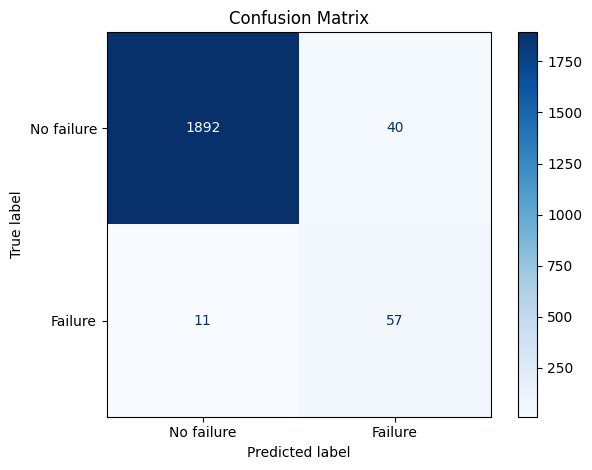

In [23]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['No failure', 'Failure'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

## Evaluation results
- Accuracy is 97% — misleading given the 3.4% failure rate
- Recall for failure class: 84% — 84% of real failures caught
- Precision for failure class: 59% — of predicted failures, only 59% were real
- False negatives (missed failures): 11 — the most costly error in production
- False positives (false alarms): 47 — predicted failure, machine was fine
- Tradeoff chosen: maximize recall, accept lower precision because missing a failure costs more than a false alarm